# 10. HAR model — all years (Method #2)
Notebook 09 did one year. Now we repeat the same three steps — **building, training, testing** — for every test year from 2007 to 2023 (the *walk-forward* of notebook 07). A `for` loop does the repeating.

* **Needs:** `work/dataset.csv`. **Makes:** `work/har_forecasts.csv`.

*Simple notebook series of the project 'This Time Is Different?'. Prepared with AI assistance (declared in `notes/ai_use.md`); a study notebook, not dissertation text.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
folder = '/content/drive/MyDrive/DataSets/ThisTimeIsDifferent/'

import warnings
warnings.filterwarnings('ignore')     # hide warning messages

In [2]:
from pandas import read_csv
dataset = read_csv(folder + 'work/dataset.csv', index_col=0, parse_dates=True)
dataset = dataset.loc[:'2023-08-31']        # main sample
print(dataset.shape)

(5243, 17)


In [3]:
from numpy import log, exp
x = log(dataset[['rv_d', 'rv_w', 'rv_m']].clip(lower=0.00000001))
y = log(dataset['rv5_fwd'])

## The loop
For each `year`: the training days run until 31 December of the year before (minus the last 5 days), and the test days are the days of `year`. Each forecast is added to a list.

In [4]:
from statsmodels.api import OLS, add_constant
forecasts = []
years = []
r2_list = []
monthly_weight = []

for year in range(2007, 2024):
    train_days = dataset.loc[:str(year - 1) + '-12-31'].dropna(subset=['rv5_fwd', 'rv_m']).index[:-5]
    test_days = dataset.loc[str(year) + '-01-01':str(year) + '-12-31'].dropna(subset=['rv5_fwd']).index

    model = OLS(y.loc[train_days], add_constant(x.loc[train_days]))        # building
    best_model = model.fit()                                                 # training
    smear = exp(best_model.resid).mean()
    y_pred = exp(best_model.predict(add_constant(x.loc[test_days], has_constant='add'))) * smear   # testing

    forecasts.append(y_pred)
    years.append(year)
    r2_list.append(best_model.rsquared)
    monthly_weight.append(best_model.params['rv_m'])
    print(year, ':', len(test_days), 'test days | R2 =', round(best_model.rsquared, 2))

2007 : 254 test days | R2 = 0.11
2008 : 254 test days | R2 = 0.25
2009 : 251 test days | R2 = 0.53
2010 : 254 test days | R2 = 0.57
2011 : 253 test days | R2 = 0.53
2012 : 254 test days | R2 = 0.52
2013 : 254 test days | R2 = 0.5
2014 : 254 test days | R2 = 0.49
2015 : 254 test days | R2 = 0.47
2016 : 254 test days | R2 = 0.46
2017 : 253 test days | R2 = 0.43
2018 : 253 test days | R2 = 0.43
2019 : 253 test days | R2 = 0.43
2020 : 256 test days | R2 = 0.42
2021 : 255 test days | R2 = 0.43
2022 : 254 test days | R2 = 0.41


2023 : 170 test days | R2 = 0.41


`concat` puts the 17 yearly pieces one after the other:

In [5]:
from pandas import concat, DataFrame
har = concat(forecasts)
print(len(har), 'forecast days')
har.head()

4230 forecast days


2007-01-02    0.000363
2007-01-03    0.000364
2007-01-04    0.000356
2007-01-05    0.000350
2007-01-08    0.000362
dtype: float64

## How the model changed over the years

In [6]:
DataFrame({'test year': years, 'R2': r2_list, 'monthly weight': monthly_weight}).round(2)

,test year,R2,monthly weight
0,2007,0.11,0.43
1,2008,0.25,0.56
2,2009,0.53,0.68
3,2010,0.57,0.73
4,2011,0.53,0.69
5,2012,0.52,0.69
6,2013,0.50,0.70
7,2014,0.49,0.71
8,2015,0.47,0.71
9,2016,0.46,0.70


R² jumps from 0.11 to about 0.5 once the 2008 crisis is in the training data: the model learns what a crisis looks like.

## Check and save

In [7]:
saved = read_csv(folder + 'results/benchmark_forecasts.csv', index_col=0, parse_dates=True)
print('largest difference from the saved HAR forecasts:', (har - saved['HAR']).abs().max())
DataFrame({'HAR': har}).to_csv(folder + 'work/har_forecasts.csv')

largest difference from the saved HAR forecasts: 1.0061396160665481e-16


## Picture: forecasts against what happened

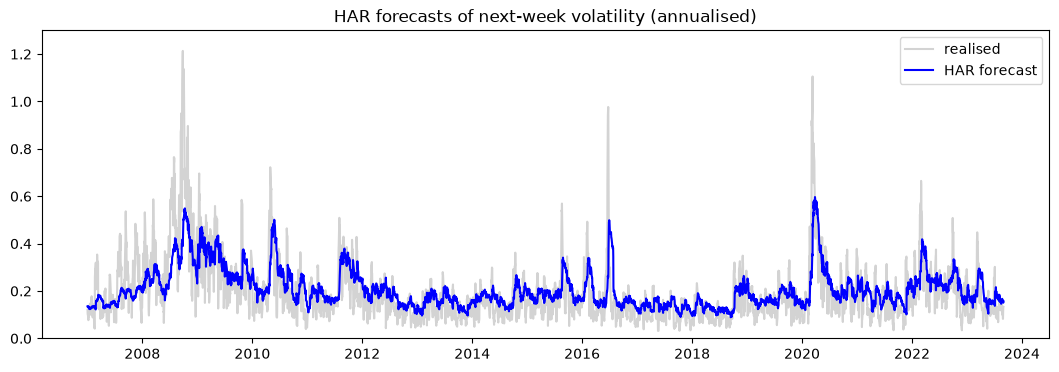

In [8]:
from numpy import sqrt
import matplotlib.pyplot as plt
plt.figure(figsize=(13, 4))
plt.plot(sqrt(dataset.loc[har.index, 'rv5_fwd'] * 252 / 5), color='lightgrey', label='realised')
plt.plot(sqrt(har * 252 / 5), color='blue', label='HAR forecast')
plt.ylim(0, 1.3)
plt.legend()
plt.title('HAR forecasts of next-week volatility (annualised)')
plt.show()